In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' ## To keep only critical logs
import time

import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras import models, callbacks, Input

# Check if GPUs are available
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Using Device: GPU ({len(gpus)} available)")
    # Optional: Display the specific name of the GPU
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("Using Device: CPU")

E0000 00:00:1780565160.325672      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780565160.392290      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780565160.931260      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780565160.931317      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780565160.931320      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780565160.931323      58 computation_placer.cc:177] computation placer already registered. Please check linka

Using Device: GPU (1 available)
  - /physical_device:GPU:0


### Modification 1: Don't set global policy
Don't set global policy as mixed precision. We'll set precision individually.

In [2]:
# policy = mixed_precision.Policy('mixed_float16')
# mixed_precision.set_global_policy(policy)
# print('Compute dtype: %s' % policy.compute_dtype)
# print('Variable dtype: %s' % policy.variable_dtype)

In [3]:
# Set up the dataset paths and labels
data_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
classes = sorted(os.listdir(data_path))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
# Build the list of file paths and labels
file_paths = []
labels = []

for cls_name in classes:
    cls_path = os.path.join(data_path, cls_name)
    for img_name in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_name))
        labels.append(class_to_idx[cls_name])

# Basic preprocessing (except augmentations)
def process_path(file_path, label):
    """
    Read the image from the path as uint8 tensor and resize it to 224, 224 and cast it to float32
    """
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)# Decode jpeg/png to a uint8 tensor
    # Resize (equivalent to transforms.Resize)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0 # Normalizing and casting happening together 
    return img, label

## Define the dataset
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))


## Split dataset into training and val as 80% for train and 20% for val
total_samples = len(file_paths)
train_size = int(0.8 * total_samples)
val_size = total_samples - train_size
full_dataset = dataset.shuffle(total_samples, reshuffle_each_iteration=False)
train_ds = full_dataset.take(train_size)
val_ds = full_dataset.skip(train_size)


I0000 00:00:1780565176.309497      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
BATCH_SIZE = 64 

## Here we create an augment function and add augmentations to the training dataset
## Both training and val datasets are converted to batches
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, label

# We create two config functions, one for train and one for val. This makes sure augmentation is only in train
def configure_train(ds):
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE) # Use the scaled batch size
    )


def configure_val(ds):
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE) # Use the scaled batch size
    )

# Apply to datasets
train_ds = configure_train(train_ds)
val_ds = configure_val(val_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.049283944..1.0335342].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.013121106..1.028287].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.017063469..0.9900198].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06613283..0.8111298].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.041984156..1.0531385].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09443648..0.96765333].


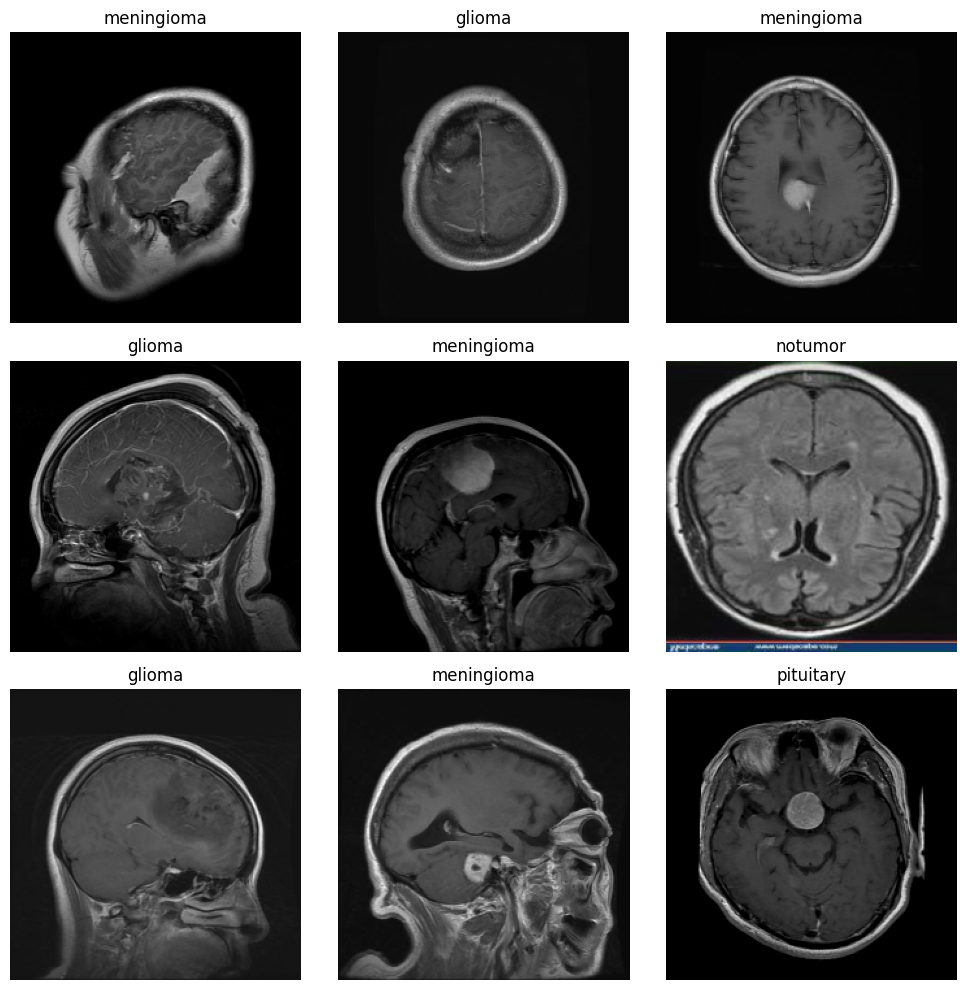

In [5]:
# Grab a batch from the dataset and plot it
images, labels = next(iter(train_ds.take(1)))

# 2. Plot a 3x3 grid
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(classes[labels[i]]) #Using the class list from earlier
    plt.axis("off")

plt.tight_layout()
plt.show()

This is how we originally planned on setting up AMP. We'll comment this out and test out how to add precision individually

In [6]:
#Set the base model
# def model_func():
#     base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
#     base_model.trainable = False 

#     # Build the model by adding the base model with classification head
#     inputs = Input(shape=(224, 224, 3))
#     x = base_model(inputs, training=False)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(256, activation='relu')(x)
#     x = layers.Dropout(0.3)(x)
#     outputs = layers.Dense(len(classes), activation='softmax',  dtype='float32')(x)
#     model = models.Model(inputs=inputs, outputs=outputs, dtype='float32') ## inputs and outputs defined functional style
#     return model


Just to demonstrate how we can define custom policy for individual layer we'll create our own custom architecture and test it out!

In [7]:
## From scratch
def create_custom_precision_model(input_shape=(224, 224, 3), num_classes=4):
    
    # Defining the two policies we'll use in the model
    fp16_policy = tf.keras.mixed_precision.DTypePolicy('mixed_float16')
    fp32_policy = tf.keras.mixed_precision.DTypePolicy('float32')
    
    # Inputs always start as FP32
    inputs = Input(shape=input_shape, name="input_layer", dtype='float32')
    
    # Feature extraction uses fp16 as it has matrix operations. These ops will happen in lower precision
    # NOTE: The weights will be stored in FP32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                      dtype=fp16_policy, name="conv_1")(inputs)
    x = layers.MaxPooling2D((2, 2), name="pool_1")(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', 
                      dtype=fp16_policy, name="conv_2")(x)
    x = layers.MaxPooling2D((2, 2), name="pool_2")(x)
    
    x = layers.Flatten(name="flatten")(x)
    
    # Using FP32 here because it feeds directly to the output layer
    x = layers.Dense(128, activation='relu', dtype=fp32_policy, name="dense_fp32")(x)
    
    # The final layer is FP32 for stability
    outputs = layers.Dense(num_classes, activation='softmax', dtype=fp32_policy, name="output_fp32")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="Custom_Precision_Model")
    return model

model=create_custom_precision_model()

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

## Verify what precision the layers use
for layer in model.layers:
    print(f"Layer: {layer.name}, Policy: {layer.dtype_policy}")


Layer: input_layer, Policy: <DTypePolicy "float32">
Layer: conv_1, Policy: <DTypePolicy "mixed_float16">
Layer: pool_1, Policy: <DTypePolicy "float32">
Layer: conv_2, Policy: <DTypePolicy "mixed_float16">
Layer: pool_2, Policy: <DTypePolicy "float32">
Layer: flatten, Policy: <DTypePolicy "float32">
Layer: dense_fp32, Policy: <DTypePolicy "float32">
Layer: output_fp32, Policy: <DTypePolicy "float32">


Let's check it out for pretrained models as well

In [8]:
# # Define Callbacks
# my_callbacks = [
#     callbacks.ModelCheckpoint(filepath='best_resnet_model.keras', monitor='val_accuracy', save_best_only=True),
#     callbacks.TensorBoard(log_dir='./logs'),
#     callbacks.EarlyStopping(monitor='val_loss', patience=10)
# ]

# # Train normally using model.fit
# start_time=time.time()
# model.fit(train_ds,validation_data=val_ds,epochs=40,callbacks=my_callbacks)
# end_time=time.time()
# print ("Training time in seconds: ", (end_time-start_time))